# Q1

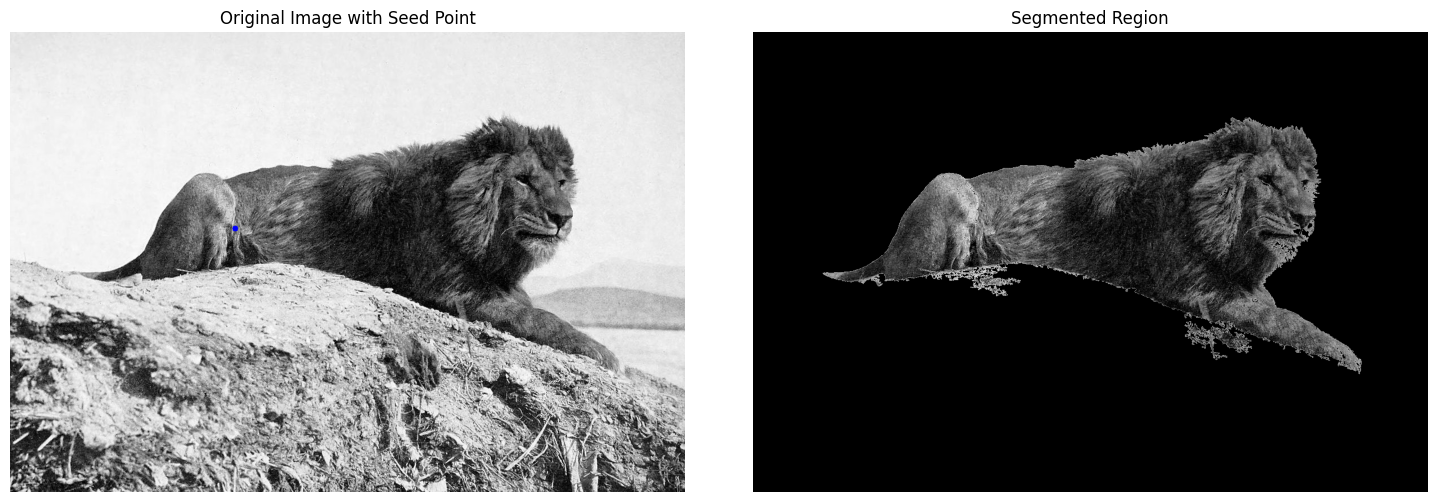

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class ImageSegmenter:
    def __init__(self, image_path):
        """Initialize the ImageSegmenter with an input image."""
        self.original = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.original, cv2.COLOR_BGR2RGB)
        self.height, self.width = self.image.shape[:2]
        self.segmentation_result = None

    def check_boundaries(self, point):
        """Check if a given point is within the image boundaries."""
        x, y = point
        return 0 <= x < self.width and 0 <= y < self.height

    def segment_image(self, seed_coordinates, similarity_threshold=180):
        """Perform region growing segmentation using a list for pixel processing."""
        result_mask = np.zeros((self.height, self.width), dtype=np.uint8)
        to_process = [(seed_coordinates, self.image[seed_coordinates[1], seed_coordinates[0]])]
        result_mask[seed_coordinates[1], seed_coordinates[0]] = 255

        #Initialize region properties
        region_sum = self.image[seed_coordinates[1], seed_coordinates[0]].copy().astype(np.float32)
        pixels_in_region = 1

        #Define neighborhood connectivity (4-connectivity)
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

        while to_process:
            (current_x, current_y), _ = to_process.pop(0)

            #Check neighboring pixels
            for dx, dy in directions:
                next_x, next_y = current_x + dx, current_y + dy

                if not self.check_boundaries((next_x, next_y)) or result_mask[next_y, next_x] != 0:
                    continue

                #Compute color similarity
                current_mean = region_sum / pixels_in_region
                color_difference = np.linalg.norm(self.image[next_y, next_x] - current_mean)

                #Add similar pixels to the region
                if color_difference < similarity_threshold:
                    result_mask[next_y, next_x] = 255
                    to_process.append(((next_x, next_y), self.image[next_y, next_x]))
                    region_sum += self.image[next_y, next_x]
                    pixels_in_region += 1

        self.segmentation_result = result_mask
        return result_mask

    def visualize_results(self, seed_point):
        """Display the segmentation results."""
        if self.segmentation_result is None:
            raise ValueError("Run segment_image first!")

        #Create visualization images
        marked_original = self.image.copy()
        cv2.circle(marked_original, seed_point, 5, (0, 0, 255), -1)  

        masked_result = cv2.bitwise_and(self.image, self.image, mask=self.segmentation_result)

        #Display results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.imshow(marked_original)
        ax1.set_title("Original Image with Seed Point")
        ax1.axis("off")

        ax2.imshow(masked_result)
        ax2.set_title("Segmented Region")
        ax2.axis("off")

        plt.tight_layout()
        plt.show()

def main():
    image_path = "Lion.jpg"
    seed_point = (400, 350)
    threshold = 180

    #Process image
    segmenter = ImageSegmenter(image_path)
    segmenter.segment_image(seed_point, threshold)
    segmenter.visualize_results(seed_point)

if __name__ == "__main__":
    main()


Displaying segmentation results for Seed Group 1: [(900, 100), (300, 360), (100, 250)]


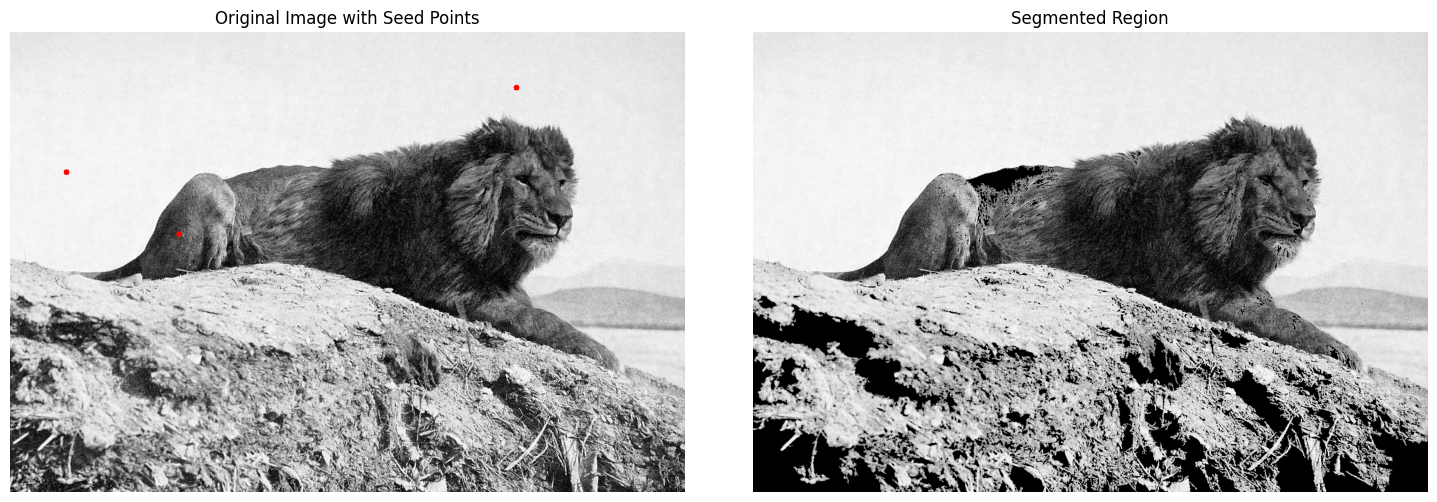

Displaying segmentation results for Seed Group 2: [(100, 190), (670, 670), (850, 700)]


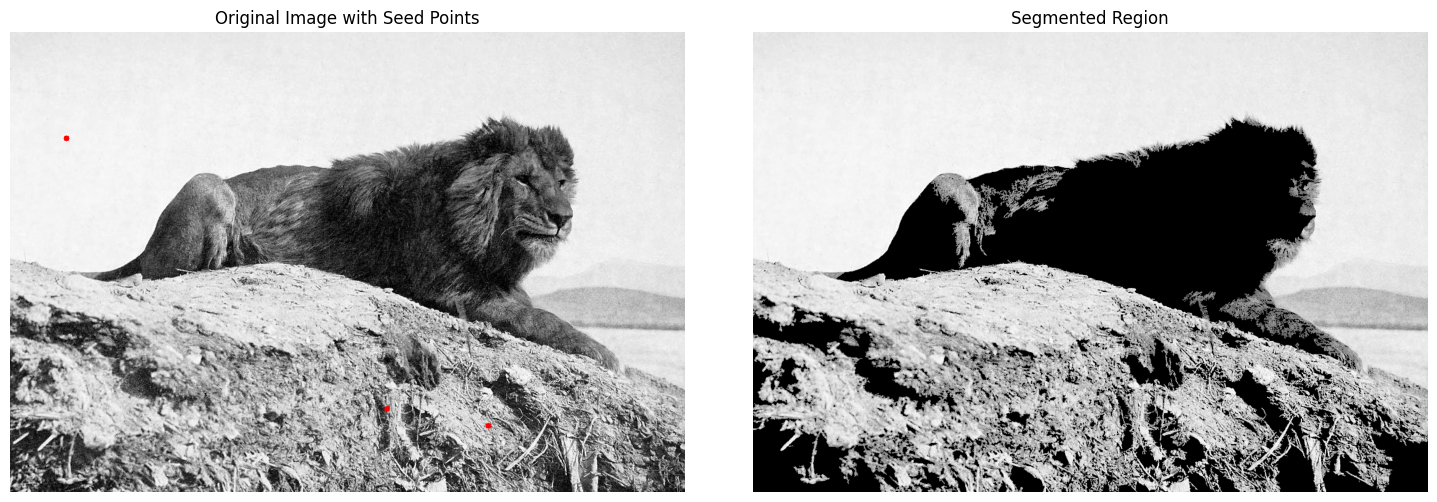

Displaying segmentation results for Seed Group 3: [(660, 360), (670, 250), (750, 360)]


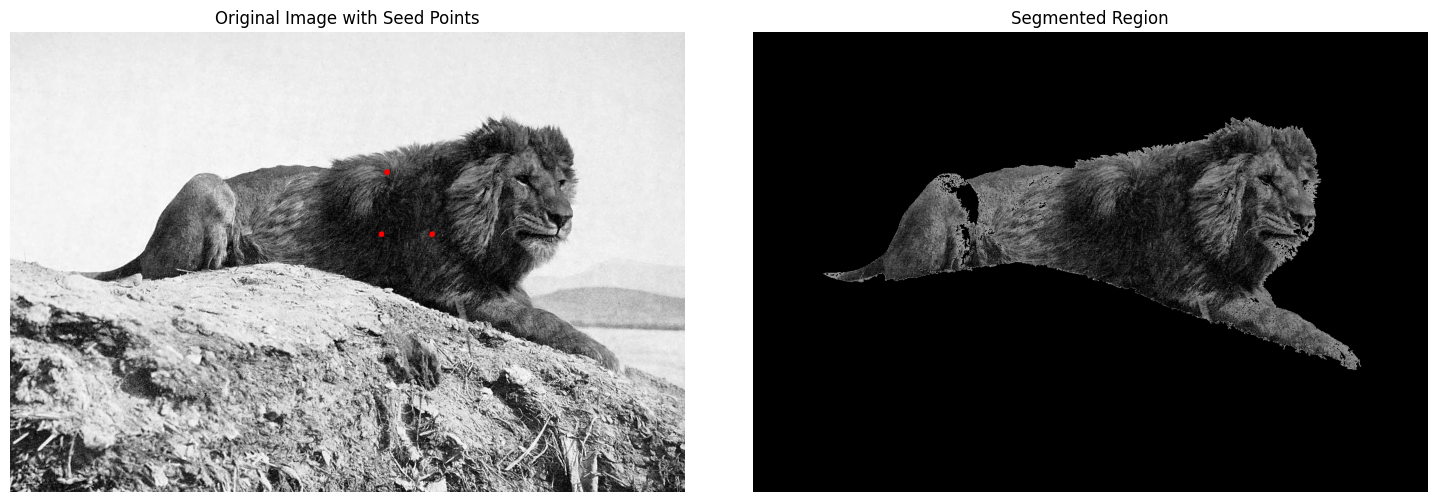

In [30]:

class MultiSeedImageSegmenterNoQueue:
    def __init__(self, image_path):
        """Initialize the ImageSegmenter with an input image."""
        self.original = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.original, cv2.COLOR_BGR2RGB)
        self.height, self.width = self.image.shape[:2]
        self.segmentation_result = None

    def check_boundaries(self, point):
        """Check if a given point is within image boundaries."""
        x, y = point
        return 0 <= x < self.width and 0 <= y < self.height

    def segment_image(self, seed_points, similarity_threshold=180):
        """Perform region growing segmentation using multiple seeds."""
        result_mask = np.zeros((self.height, self.width), dtype=np.uint8)
        pixel_stack = list(seed_points)  # Using list as a stack

        #Mark initial seeds in the mask and track regions
        seed_labels = {}
        for idx, (x, y) in enumerate(seed_points):
            result_mask[y, x] = 255
            seed_labels[(x, y)] = idx

        #Initialize region properties
        region_sums = [self.image[y, x].astype(np.float32) for x, y in seed_points]
        pixels_in_regions = [1] * len(seed_points)

        #Define neighborhood connectivity (4-connectivity)
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

        while pixel_stack:
            current_x, current_y = pixel_stack.pop()  

            #Identify the region this pixel belongs to
            seed_idx = seed_labels[(current_x, current_y)]

            #Check neighboring pixels
            for dx, dy in directions:
                next_x, next_y = current_x + dx, current_y + dy

                if not self.check_boundaries((next_x, next_y)) or result_mask[next_y, next_x] != 0:
                    continue

                #Compute color similarity for the corresponding region
                current_mean = region_sums[seed_idx] / pixels_in_regions[seed_idx]
                color_difference = np.linalg.norm(self.image[next_y, next_x] - current_mean)

                #Add similar pixels to the region
                if color_difference < similarity_threshold:
                    result_mask[next_y, next_x] = 255
                    pixel_stack.append((next_x, next_y))
                    region_sums[seed_idx] += self.image[next_y, next_x]
                    pixels_in_regions[seed_idx] += 1
                    seed_labels[(next_x, next_y)] = seed_idx 

        self.segmentation_result = result_mask
        return result_mask

    def visualize_results(self, seed_points):
        """Display the segmentation results."""
        if self.segmentation_result is None:
            raise ValueError("Run segment_image first!")

        #Create visualization images
        marked_original = self.image.copy()
        for seed in seed_points:
            cv2.circle(marked_original, seed, 5, (255, 0, 0), -1)  # Mark the seed points in red

        masked_result = cv2.bitwise_and(self.image, self.image, mask=self.segmentation_result)

        #Display results
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.imshow(marked_original)
        ax1.set_title("Original Image with Seed Points")
        ax1.axis("off")

        ax2.imshow(masked_result, cmap="gray")
        ax2.set_title("Segmented Region")
        ax2.axis("off")

        plt.tight_layout()
        plt.show()


#Load and process the lion image with multiple seed points in one image
seed_sets = [
    [(900, 100), (300, 360), (100, 250)],
    [(100, 190), (670, 670), (850, 700)],
    [(660, 360), (670, 250), (750, 360)]
]

threshold = 180

for i, seed_group in enumerate(seed_sets):
    segmenter = MultiSeedImageSegmenterNoQueue(image_path)
    segmenter.segment_image(seed_group, threshold)
    print(f"Displaying segmentation results for Seed Group {i + 1}: {seed_group}")
    segmenter.visualize_results(seed_group)


In [23]:

def visualize_multiple_seeds(self, seed_sets):
    """Display segmentation results for multiple sets of seed points."""
    num_sets = len(seed_sets)
    fig, axes = plt.subplots(num_sets, 2, figsize=(15, 5*num_sets))
    
    for i, seed_set in enumerate(seed_sets):
        #Create a combined mask for all seeds in this set
        combined_mask = np.zeros((self.height, self.width), dtype=np.uint8)
        marked_original = self.image.copy()
        
        #Process each seed point in the set
        for seed_point in seed_set:
            #Mark seed point on original image
            cv2.circle(marked_original, seed_point, 5, (0, 0, 255), -1)
            
            #Segment for this seed point
            mask = self.segment_image(seed_point)
            combined_mask = cv2.bitwise_or(combined_mask, mask)
        
        #Create masked result
        masked_result = cv2.bitwise_and(self.image, self.image, mask=combined_mask)
        
        #Display results
        axes[i, 0].imshow(marked_original)
        axes[i, 0].set_title(f"Set {i+1}: Original Image with Seed Points")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(masked_result)
        axes[i, 1].set_title(f"Set {i+1}: Segmented Region")
        axes[i, 1].axis("off")
    
    plt.tight_layout()
    plt.show()

# Q2.


I executed the following code in Google Colab and saved the outputs for the report. Below, I am providing the code for reference.

In [19]:
"""

% pip install diffusers transformers accelerate --upgrade
% pip install huggingface_hub

"""



'\n\n% pip install diffusers transformers accelerate --upgrade\n% pip install huggingface_hub\n\n'

In [20]:
"""

from huggingface_hub import login

login()
"""


'\n\nfrom huggingface_hub import login\n\nlogin()\n'

In [18]:
"""

from diffusers import StableDiffusionPipeline
import torch

#Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe.to("cuda")  # Move the model to GPU

#Define the prompt
prompt = "A futuristic city where robots are eating kebabs and laughing at humans"

#Generate the image
image = pipe(prompt).images[0]

#Save the image to a file
image.save("generated_image.png")

#Display the image inline in the notebook
from IPython.display import display
display(image)

"""


'\n\nfrom diffusers import StableDiffusionPipeline\nimport torch\n\n# Load the pipeline\npipe = StableDiffusionPipeline.from_pretrained(\n    "runwayml/stable-diffusion-v1-5",\n    torch_dtype=torch.float16\n)\npipe.to("cuda")  # Move the model to GPU\n\n# Define the prompt\nprompt = "A futuristic city where robots are eating kebabs and laughing at humans"\n\n# Generate the image\nimage = pipe(prompt).images[0]\n\n# Save the image to a file\nimage.save("generated_image.png")\n\n# Display the image inline in the notebook\nfrom IPython.display import display\ndisplay(image)\n\n'

In [17]:
"""

# Install necessary libraries
%pip install diffusers transformers accelerate Pillow

#Import libraries
from diffusers import StableDiffusionImg2ImgPipeline
import torch
from PIL import Image
import requests
from io import BytesIO

#Load the Image-to-Image pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", 
    torch_dtype=torch.float16
)
pipe.to("cuda")  # Move the pipeline to GPU for faster processing

#Load an input image
image_url = "https://images.pexels.com/photos/1030794/pexels-photo-1030794.jpeg?auto=compress&cs=tinysrgb&w=600"  # Replace with your input image URL
response = requests.get(image_url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")  # Fixed: Proper binary handling
init_image = init_image.resize((512, 512))  # Resize to match model's expected input size

#Define the text prompt for transformation
prompt = "Add yellow sun and moon into the sky of the given scene"

#Generate the transformed image
print("Generating image...")
strength = 0.8  # How much the model modifies the image (1.0 = full, 0.0 = no change)
guidance_scale = 7.5  # Higher values lead to more adherence to the text prompt
output = pipe(prompt=prompt, image=init_image, strength=strength, guidance_scale=guidance_scale)

#Save and display the output image
output_image = output.images[0]
output_image.save("output_image.png")
output_image.show()

print("Image saved as output_image.png")

"""


'\n\n# Install necessary libraries\n%pip install diffusers transformers accelerate Pillow\n\n# Import libraries\nfrom diffusers import StableDiffusionImg2ImgPipeline\nimport torch\nfrom PIL import Image\nimport requests\nfrom io import BytesIO\n\n# Load the Image-to-Image pipeline\npipe = StableDiffusionImg2ImgPipeline.from_pretrained(\n    "runwayml/stable-diffusion-v1-5", \n    torch_dtype=torch.float16\n)\npipe.to("cuda")  # Move the pipeline to GPU for faster processing\n\n# Load an input image\nimage_url = "https://images.pexels.com/photos/1030794/pexels-photo-1030794.jpeg?auto=compress&cs=tinysrgb&w=600"  # Replace with your input image URL\nresponse = requests.get(image_url)\ninit_image = Image.open(BytesIO(response.content)).convert("RGB")  # Fixed: Proper binary handling\ninit_image = init_image.resize((512, 512))  # Resize to match model\'s expected input size\n\n# Define the text prompt for transformation\nprompt = "Add yellow sun and moon into the sky of the given scene"\n\

# Q3.


In [16]:
import cv2 as cv
import numpy as np
import os
from PIL import Image
import glob
import matplotlib.pyplot as plt

def frames_from_video(video_path, save_path, extraction_rate=1):
    """
    Extract frames from a video file and save them.

    Args:
        video_path (str): Path to the video file.
        save_path (str): Directory to save extracted frames.
        extraction_rate (int): Extract one frame every `extraction_rate` seconds.
    """
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    cap = cv.VideoCapture(video_path)
    fps = int(cap.get(cv.CAP_PROP_FPS))
    frame_interval = fps * extraction_rate
    
    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            frame_name = os.path.join(save_path, f"frame_{saved_count}.png")
            cv.imwrite(frame_name, frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    print(f"Frames saved in {save_path}")


def optical_flow(frames_saved_path):
    """
    Compute optical flow using Lucas-Kanade method.

    Args:
        frames_saved_path (str): Path to saved frames.
    """
    frames_path = sorted(glob.glob(os.path.join(frames_saved_path, '*.png')))
    frames_images = [cv.imread(frame) for frame in frames_path]

    #Shi-Tomasi corner detection parameters
    feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

    #Lucas-Kanade optical flow parameters
    lk_params = dict(winSize=(15, 15), maxLevel=2, criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03))

    #Random colors for visualization
    color = np.random.randint(0, 255, (100, 3))

    #First frame processing
    first_frame = frames_images[0]
    first_gray = cv.cvtColor(first_frame, cv.COLOR_BGR2GRAY)
    p0 = cv.goodFeaturesToTrack(first_gray, mask=None, **feature_params)

    #Create a mask image for drawing purposes
    mask = np.zeros_like(first_frame)

    #Ensure tracking starts immediately by initializing points with the first frame
    if p0 is None:
        print("No features detected in the first frame. Initializing random points.")
        h, w = first_gray.shape
        p0 = np.array([[[x, y]] for y in range(0, h, h // 10) for x in range(0, w, w // 10)], dtype=np.float32)

    for i in range(1, len(frames_images)):
        frame = frames_images[i]
        frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

        #Calculate optical flow
        p1, st, err = cv.calcOpticalFlowPyrLK(first_gray, frame_gray, p0, None, **lk_params)

        #Select good points
        if p1 is not None:
            good_new = p1[st == 1]
            good_old = p0[st == 1]

            #Draw the tracks
            for j, (new, old) in enumerate(zip(good_new, good_old)):
                a, b = new.ravel()
                c, d = old.ravel()
                mask = cv.line(mask, (int(a), int(b)), (int(c), int(d)), color[j].tolist(), 2)
                frame = cv.circle(frame, (int(a), int(b)), 5, color[j].tolist(), -1)

            output = cv.add(frame, mask)
            cv.imshow('Optical Flow', output)

            #Save the resulting frame with tracks
            cv.imwrite(os.path.join(frames_saved_path, f"optical_flow_{i}.png"), output)

            if cv.waitKey(30) & 0xFF == 27:
                break

            first_gray = frame_gray.copy()
            p0 = good_new.reshape(-1, 1, 2)

    cv.destroyAllWindows()


def create_video_from_frames(frames_path, output_video_path):
    """
    Create a video from saved frames.

    Args:
        frames_path (str): Path to saved frames.
        output_video_path (str): Path to save the output video.
    """
    frames = sorted(glob.glob(os.path.join(frames_path, '*.png')))
    
    if len(frames) == 0:
        print("No frames to create a video.")
        return

    frame = cv.imread(frames[0])
    height, width, layers = frame.shape
    
    video = cv.VideoWriter(output_video_path, cv.VideoWriter_fourcc(*'mp4v'), 10, (width, height))

    for frame_file in frames:
        frame = cv.imread(frame_file)
        video.write(frame)

    video.release()
    print(f"Video saved at {output_video_path}")

video_path = "path_to_your_video.mp4"
save_frames_path = "frames"
output_video_path = "output_video.mp4"

frames_from_video(video_path, save_frames_path)
optical_flow(save_frames_path)
create_video_from_frames(save_frames_path, output_video_path)


Frames saved in frames
Video saved at output_video.mp4


# Q4.


c:\Users\eyeke\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\eyeke\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10
Train Loss: 1.130 | Train Acc: 44.44%
Val Loss: 0.201 | Val Acc: 94.44%
Epoch 2/10
Train Loss: 0.078 | Train Acc: 100.00%
Val Loss: 0.147 | Val Acc: 94.44%
Epoch 3/10
Train Loss: 0.004 | Train Acc: 100.00%
Val Loss: 0.183 | Val Acc: 94.44%
Epoch 4/10
Train Loss: 0.001 | Train Acc: 100.00%
Val Loss: 0.182 | Val Acc: 94.44%
Epoch 5/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.177 | Val Acc: 94.44%
Epoch 6/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.174 | Val Acc: 94.44%
Epoch 7/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.176 | Val Acc: 94.44%
Epoch 8/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.179 | Val Acc: 94.44%
Epoch 9/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.183 | Val Acc: 94.44%
Epoch 10/10
Train Loss: 0.000 | Train Acc: 100.00%
Val Loss: 0.192 | Val Acc: 94.44%


C:\Users\eyeke\AppData\Local\Temp\ipykernel_17316\6470931.py:209: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transfer_learning.model.load_state_dict(torch.load(transfer_l

Extracting basic features...


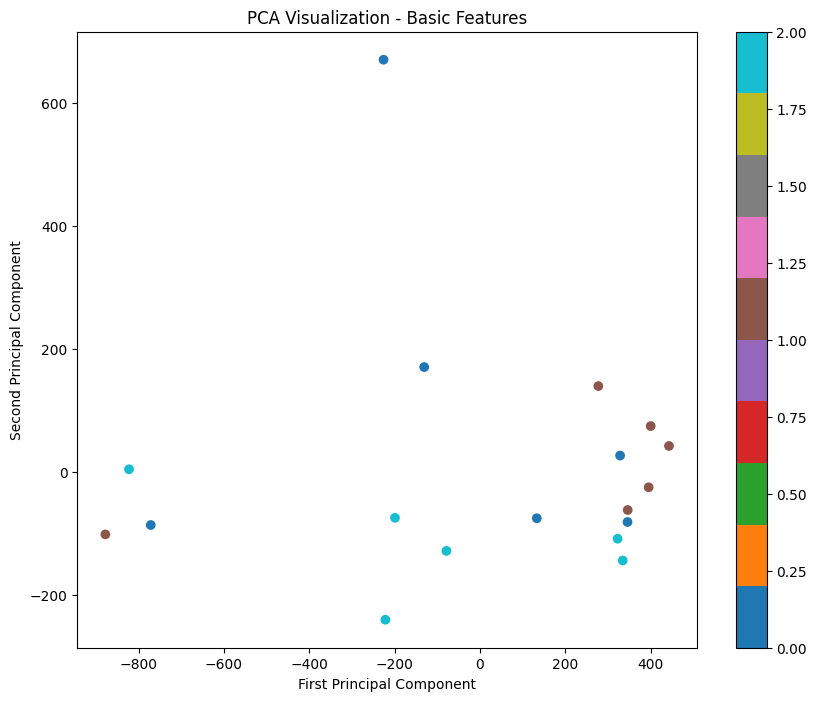

Explained variance ratio: [0.5103543 0.0988277]


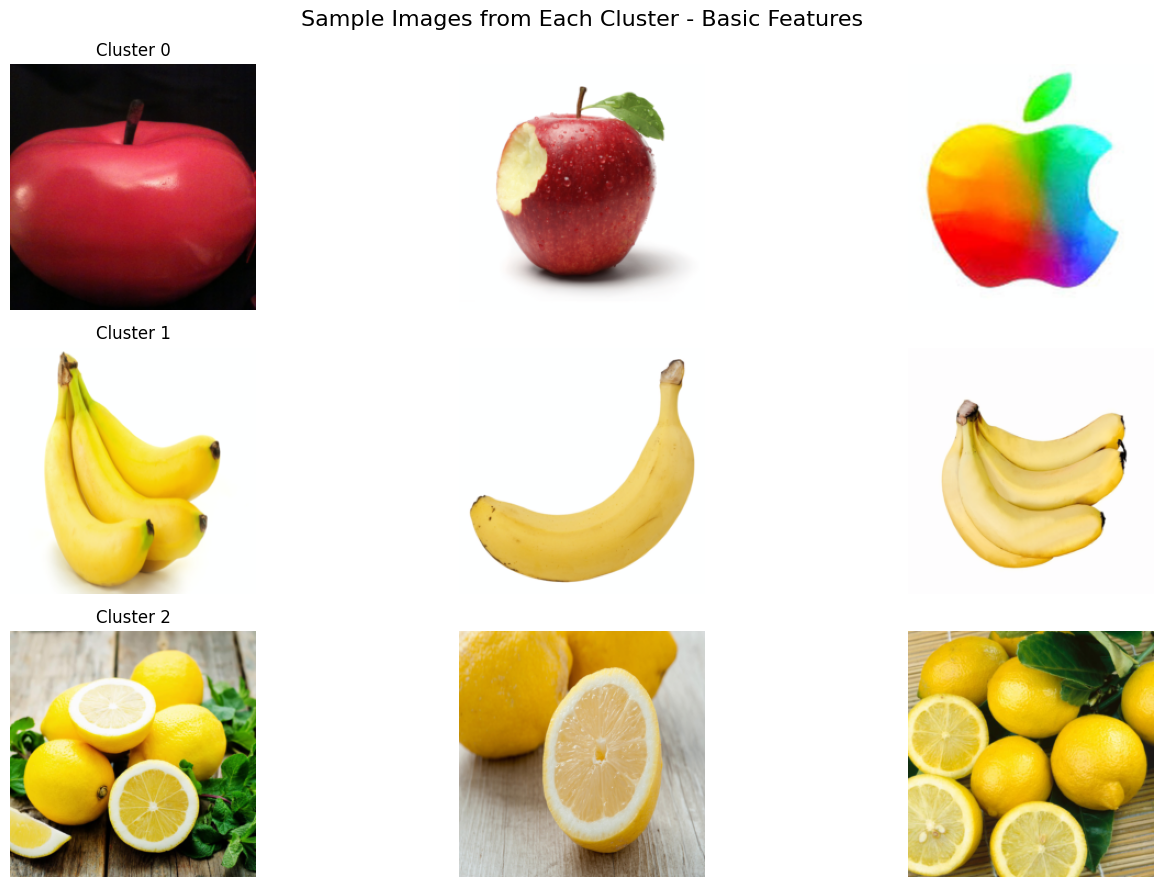

Extracting learned features...


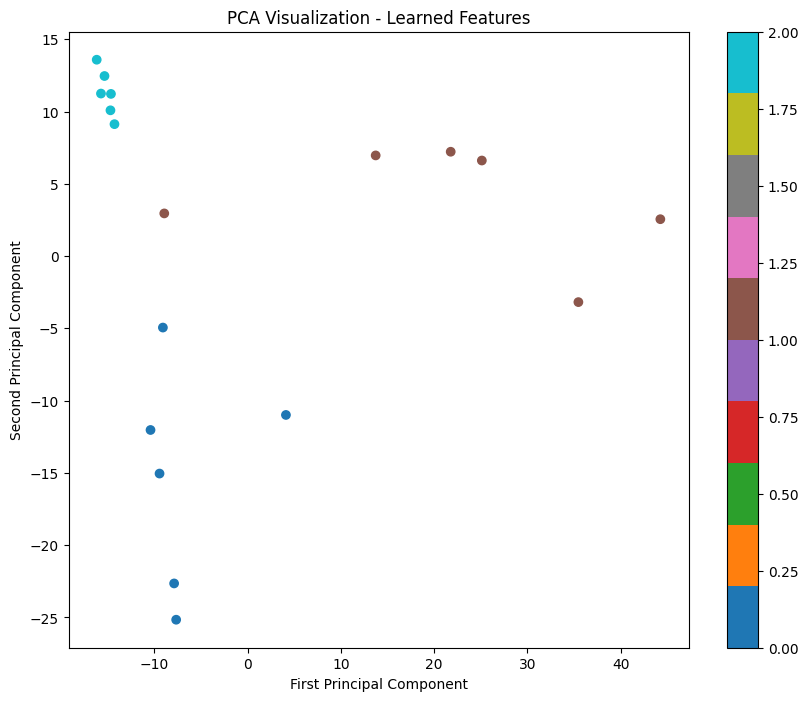

Explained variance ratio: [0.47953266 0.19578163]


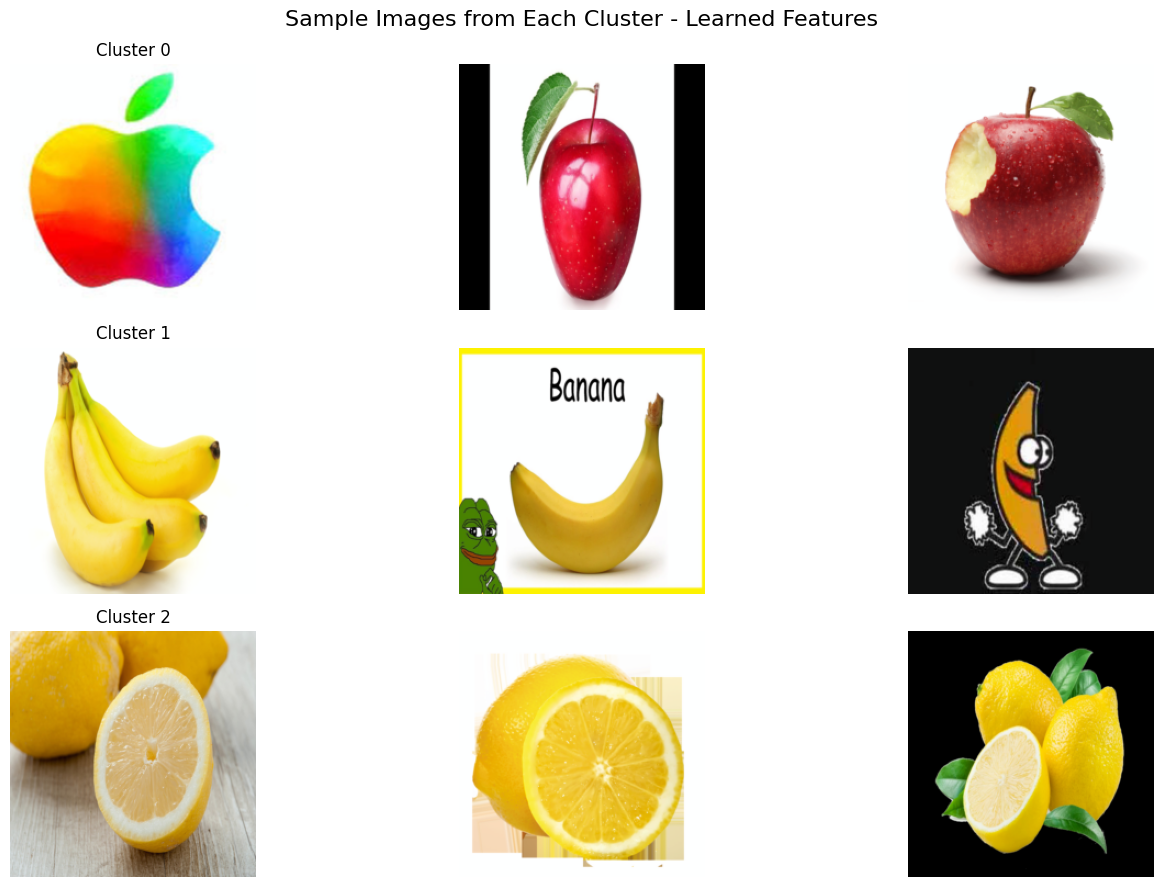


Analysis of Results:
1. Basic Feature Extraction (Raw Pixels):
   - Clusters based on raw pixel values
   - More sensitive to lighting and background variations
   - Less semantic meaning in groupings

2. Learned Feature Extraction (ResNet):
   - Clusters based on high-level features
   - More robust to variations in lighting and pose
   - Better semantic grouping of similar objects


In [15]:
## QUESTION 4-) PCA / Feature Extraction

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        #Remove the last FC layer
        self.features = nn.Sequential(*list(model.children())[:-1])
    
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

class TransferLearning:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model_save_path = "best_model.pth"
        
        #Data transforms
        self.data_transforms = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        #Load datasets
        self.train_dataset = datasets.ImageFolder(root='train', transform=self.data_transforms)
        self.val_dataset = datasets.ImageFolder(root='val', transform=self.data_transforms)
        self.test_dataset = datasets.ImageFolder(root='test', transform=self.data_transforms)
        
        self.train_loader = DataLoader(self.train_dataset, batch_size=32, shuffle=True)
        self.val_loader = DataLoader(self.val_dataset, batch_size=32, shuffle=False)
        self.test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        
        #Initialize model
        self.model = models.resnet50(pretrained=True)
        
        #Freeze all layers except last few
        for name, param in self.model.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        
        #Modify final layer
        num_classes = len(self.train_dataset.classes)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.model = self.model.to(self.device)
        
        #Loss and optimizer
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
    
    def train_model(self, num_epochs=10):
        best_acc = 0.0
        
        for epoch in range(num_epochs):
            #Training phase
            self.model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            
            for inputs, labels in self.train_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
            
            train_acc = 100. * correct / total
            
            #Validation phase
            val_loss, val_acc = self.validate()
            
            print(f'Epoch {epoch+1}/{num_epochs}')
            print(f'Train Loss: {running_loss/len(self.train_loader):.3f} | Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%')
            
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(self.model.state_dict(), self.model_save_path)
    
    def validate(self):
        self.model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in self.val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        return val_loss/len(self.val_loader), 100.*correct/total
    
    def extract_features(self):
        #Create feature extractor
        feature_extractor = FeatureExtractor(self.model).to(self.device)
        feature_extractor.eval()
        
        features = []
        labels = []
        
        with torch.no_grad():
            for inputs, targets in self.test_loader:
                inputs = inputs.to(self.device)
                batch_features = feature_extractor(inputs)
                features.append(batch_features.cpu().numpy())
                labels.extend(targets.numpy())
        
        features = np.concatenate(features, axis=0)
        return features, np.array(labels)
    
    def basic_feature_extraction(self):
        features = []
        labels = []
        
        for inputs, targets in self.test_loader:
            batch_features = inputs.view(inputs.size(0), -1).numpy()
            features.append(batch_features)
            labels.extend(targets.numpy())
        
        return np.concatenate(features, axis=0), np.array(labels)
    
    def visualize_pca(self, features, labels, title):
        #Apply PCA
        pca = PCA(n_components=2)
        features_pca = pca.fit_transform(features)
        
        #Plot results
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap='tab10')
        plt.title(f'PCA Visualization - {title}')
        plt.xlabel('First Principal Component')
        plt.ylabel('Second Principal Component')
        plt.colorbar(scatter)
        plt.show()
        
        #Print explained variance ratio
        print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

    def visualize_cluster_samples(self, features_pca, labels, original_images, title, n_samples=3):
        """Visualize sample images from each cluster"""
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels)
        
        #Create a figure with subplots for each cluster
        fig = plt.figure(figsize=(15, 3*n_clusters))
        plt.suptitle(f'Sample Images from Each Cluster - {title}', size=16)
        
        for i, label in enumerate(unique_labels):
            #Get indices for this cluster
            cluster_indices = np.where(labels == label)[0]
            
            #Get sample images from this cluster
            sample_indices = np.random.choice(cluster_indices, min(n_samples, len(cluster_indices)), replace=False)
            
            for j, idx in enumerate(sample_indices):
                ax = fig.add_subplot(n_clusters, n_samples, i*n_samples + j + 1)
                img = original_images[idx]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_title(f'Cluster {label}')
        
        plt.tight_layout()
        plt.show()

    def get_original_images(self):
        """Get original images from test dataset"""
        original_images = []
        for inputs, _ in self.test_loader:
            #Convert tensor to numpy and denormalize
            imgs = inputs.numpy()
            imgs = np.transpose(imgs, (0, 2, 3, 1))  # Change from BCHW to BHWC
            imgs = imgs * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            imgs = np.clip(imgs, 0, 1)
            original_images.extend(imgs)
        return np.array(original_images)

def main():
    transfer_learning = TransferLearning()
    
    transfer_learning.train_model()
    
    #Load best model
    transfer_learning.model.load_state_dict(torch.load(transfer_learning.model_save_path))
    
    #Get original images for visualization
    original_images = transfer_learning.get_original_images()
    
    #Basic feature extraction and visualization
    print("Extracting basic features...")
    basic_features, basic_labels = transfer_learning.basic_feature_extraction()
    basic_pca = transfer_learning.visualize_pca(basic_features, basic_labels, "Basic Features")
    transfer_learning.visualize_cluster_samples(basic_pca, basic_labels, original_images, "Basic Features")
    
    #Learned feature extraction and visualization
    print("Extracting learned features...")
    learned_features, learned_labels = transfer_learning.extract_features()
    learned_pca = transfer_learning.visualize_pca(learned_features, learned_labels, "Learned Features")
    transfer_learning.visualize_cluster_samples(learned_pca, learned_labels, original_images, "Learned Features")
    
    #Analysis
    print("\nAnalysis of Results:")
    print("1. Basic Feature Extraction (Raw Pixels):")
    print("   - Clusters based on raw pixel values")
    print("   - More sensitive to lighting and background variations")
    print("   - Less semantic meaning in groupings")
    
    print("\n2. Learned Feature Extraction (ResNet):")
    print("   - Clusters based on high-level features")
    print("   - More robust to variations in lighting and pose")
    print("   - Better semantic grouping of similar objects")

if __name__ == "__main__":
    main()
